In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CBCT_to_sCT_Project

Mounted at /content/drive
/content/drive/MyDrive/CBCT_to_sCT_Project


In [2]:
!pip install -q SimpleITK pandas matplotlib numpy torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.0 MB/s eta 0:00:00


In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

In [4]:
df = pd.read_csv("data/patient_list.csv")

print("Total patients:", len(df))
print(df.head())
print(df["region"].value_counts())

Total patients: 774
  patient_id region           patient_path                       cbct_path  \
0    2ABA002     AB  data/Task2/AB/2ABA002  data/Task2/AB/2ABA002/cbct.mha   
1    2ABA005     AB  data/Task2/AB/2ABA005  data/Task2/AB/2ABA005/cbct.mha   
2    2ABA006     AB  data/Task2/AB/2ABA006  data/Task2/AB/2ABA006/cbct.mha   
3    2ABA008     AB  data/Task2/AB/2ABA008  data/Task2/AB/2ABA008/cbct.mha   
4    2ABA009     AB  data/Task2/AB/2ABA009  data/Task2/AB/2ABA009/cbct.mha   

                        ct_path                       mask_path  has_cbct  \
0  data/Task2/AB/2ABA002/ct.mha  data/Task2/AB/2ABA002/mask.mha      True   
1  data/Task2/AB/2ABA005/ct.mha  data/Task2/AB/2ABA005/mask.mha      True   
2  data/Task2/AB/2ABA006/ct.mha  data/Task2/AB/2ABA006/mask.mha      True   
3  data/Task2/AB/2ABA008/ct.mha  data/Task2/AB/2ABA008/mask.mha      True   
4  data/Task2/AB/2ABA009/ct.mha  data/Task2/AB/2ABA009/mask.mha      True   

   has_ct  has_mask  
0    True      True  
1   

In [5]:
from sklearn.model_selection import KFold
import os
import json

os.makedirs("splits", exist_ok=True)

patient_ids = df["patient_id"].unique()

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(patient_ids)):
    train_patients = patient_ids[train_idx].tolist()
    val_patients = patient_ids[val_idx].tolist()

    split = {
        "train": train_patients,
        "val": val_patients
    }

    with open(f"splits/fold_{fold}.json", "w") as f:
        json.dump(split, f, indent=4)

    print(f"Fold {fold}")
    print("Train patients:", len(train_patients))
    print("Val patients:", len(val_patients))
    print()

Fold 0
Train patients: 516
Val patients: 258

Fold 1
Train patients: 516
Val patients: 258

Fold 2
Train patients: 516
Val patients: 258



In [6]:
%%writefile src/dataset.py
import numpy as np
import torch
from torch.utils.data import Dataset

from .preprocessing import (
    read_mha,
    normalize_hu,
    prepare_mask,
    center_crop_or_pad_3d
)


class SynthRAD2p5DDataset(Dataset):


    def __init__(
        self,
        dataframe,
        patient_ids,
        input_slices=7,
        image_size=320,
        min_hu=-1000,
        max_hu=1600,
        use_mask=True,
        max_patients=None
    ):
        self.dataframe = dataframe[dataframe["patient_id"].isin(patient_ids)].reset_index(drop=True)

        if max_patients is not None:
            self.dataframe = self.dataframe.iloc[:max_patients].reset_index(drop=True)

        self.input_slices = input_slices
        self.half = input_slices // 2
        self.image_size = image_size
        self.min_hu = min_hu
        self.max_hu = max_hu
        self.use_mask = use_mask

        self.volumes = {}
        self.index = []

        self._load_volumes_and_build_index()

    def _load_volumes_and_build_index(self):
        for _, row in self.dataframe.iterrows():
            patient_id = row["patient_id"]

            _, cbct, _, _, _ = read_mha(row["cbct_path"])
            _, ct, _, _, _ = read_mha(row["ct_path"])
            _, mask, _, _, _ = read_mha(row["mask_path"])

            cbct = normalize_hu(cbct, self.min_hu, self.max_hu)
            ct = normalize_hu(ct, self.min_hu, self.max_hu)
            mask = prepare_mask(mask)

            cbct = center_crop_or_pad_3d(
                cbct,
                target_size=self.image_size,
                pad_value=-1
            )

            ct = center_crop_or_pad_3d(
                ct,
                target_size=self.image_size,
                pad_value=-1
            )

            mask = center_crop_or_pad_3d(
                mask,
                target_size=self.image_size,
                pad_value=0
            )

            self.volumes[patient_id] = {
                "cbct": cbct,
                "ct": ct,
                "mask": mask,
                "region": row["region"]
            }

            num_slices = cbct.shape[0]


            for z in range(self.half, num_slices - self.half):

                if self.use_mask:
                    body_fraction = mask[z].mean()
                    if body_fraction < 0.01:
                        continue

                self.index.append((patient_id, z))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        patient_id, z = self.index[idx]

        cbct = self.volumes[patient_id]["cbct"]
        ct = self.volumes[patient_id]["ct"]
        mask = self.volumes[patient_id]["mask"]

        cbct_stack = cbct[z - self.half : z + self.half + 1]
        ct_slice = ct[z]
        mask_slice = mask[z]

        cbct_stack = torch.tensor(cbct_stack, dtype=torch.float32)
        ct_slice = torch.tensor(ct_slice[None, :, :], dtype=torch.float32)
        mask_slice = torch.tensor(mask_slice[None, :, :], dtype=torch.float32)

        return {
            "input": cbct_stack,
            "target": ct_slice,
            "mask": mask_slice,
            "patient_id": patient_id,
            "slice_index": z
        }

Writing src/dataset.py


In [7]:
import json
import pandas as pd
from torch.utils.data import DataLoader

from src.dataset import SynthRAD2p5DDataset

df = pd.read_csv("data/patient_list.csv")

with open("splits/fold_0.json", "r") as f:
    split = json.load(f)

small_dataset = SynthRAD2p5DDataset(
    dataframe=df,
    patient_ids=split["train"],
    input_slices=7,
    image_size=320,
    min_hu=-1000,
    max_hu=1600,
    max_patients=3
)

print("Number of 2.5D samples:", len(small_dataset))

Number of 2.5D samples: 229


In [8]:
sample = small_dataset[0]

print("Input shape:", sample["input"].shape)
print("Target shape:", sample["target"].shape)
print("Mask shape:", sample["mask"].shape)
print("Patient:", sample["patient_id"])
print("Slice index:", sample["slice_index"])

print("Input min/max:", sample["input"].min().item(), sample["input"].max().item())
print("Target min/max:", sample["target"].min().item(), sample["target"].max().item())
print("Mask values:", torch.unique(sample["mask"]))

Input shape: torch.Size([7, 320, 320])
Target shape: torch.Size([1, 320, 320])
Mask shape: torch.Size([1, 320, 320])
Patient: 2ABA002
Slice index: 6
Input min/max: -1.0 0.13846154510974884
Target min/max: -1.0 0.6446154117584229
Mask values: tensor([0., 1.])


In [9]:
loader = DataLoader(
    small_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

batch = next(iter(loader))

print("Batch input shape:", batch["input"].shape)
print("Batch target shape:", batch["target"].shape)
print("Batch mask shape:", batch["mask"].shape)

Batch input shape: torch.Size([2, 7, 320, 320])
Batch target shape: torch.Size([2, 1, 320, 320])
Batch mask shape: torch.Size([2, 1, 320, 320])


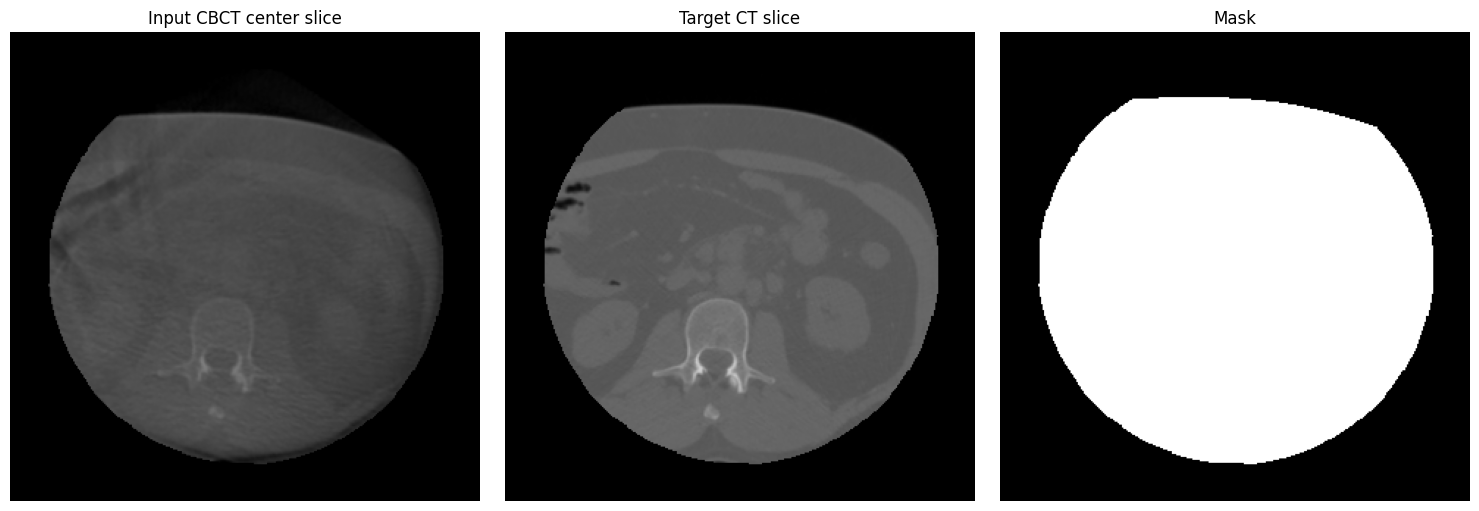

In [10]:
sample = small_dataset[30]

cbct_stack = sample["input"].numpy()
ct_slice = sample["target"][0].numpy()
mask_slice = sample["mask"][0].numpy()

center = cbct_stack.shape[0] // 2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cbct_stack[center], cmap="gray", vmin=-1, vmax=1)
plt.title("Input CBCT center slice")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ct_slice, cmap="gray", vmin=-1, vmax=1)
plt.title("Target CT slice")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_slice, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

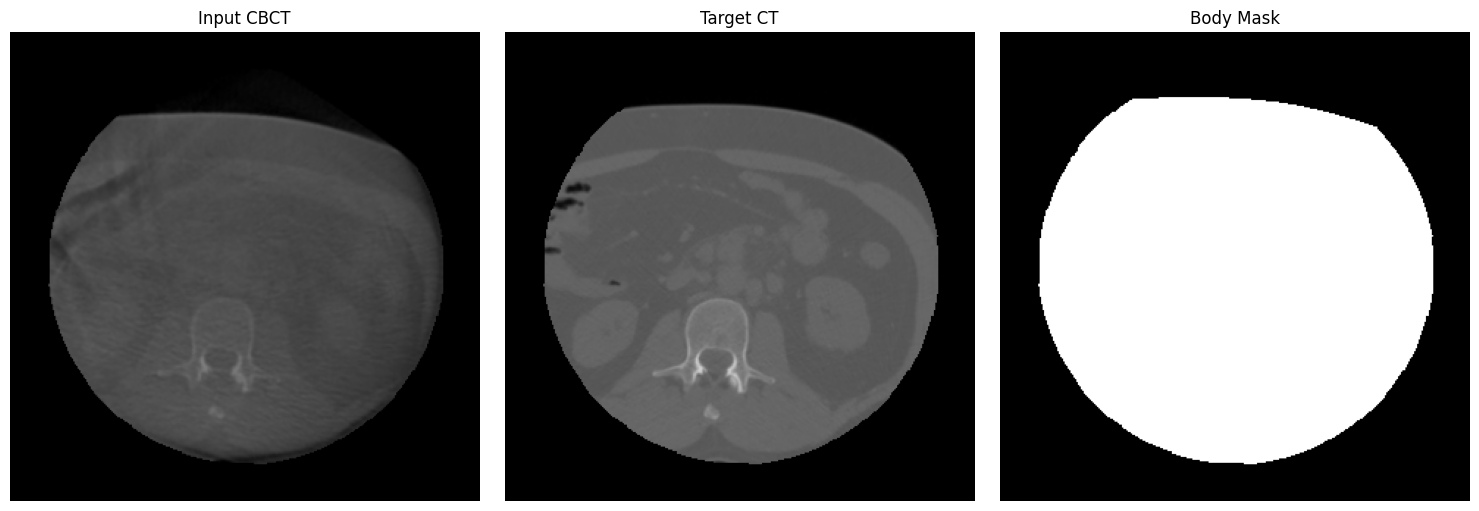

In [11]:
os.makedirs("results/figures/dataset_examples", exist_ok=True)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cbct_stack[center], cmap="gray", vmin=-1, vmax=1)
plt.title("Input CBCT")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ct_slice, cmap="gray", vmin=-1, vmax=1)
plt.title("Target CT")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_slice, cmap="gray")
plt.title("Body Mask")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/figures/dataset_examples/2p5d_dataset_sample.png", dpi=200)
plt.show()